### Import Required Libraries

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (roc_curve, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.ensemble import RandomForestClassifier

### Load Model Results and Predictions

Load the saved model performance metrics generated in the previous notebook.

In [7]:
results = pd.read_csv("../Data/Processed/model_results.csv")
results

,Model,Accuracy,ROC_AUC
0,LogReg_Gene,1.000000,1.0
1,LogReg_miRNA,0.933333,1.0
2,RF_Gene,1.000000,1.0
3,RF_miRNA,0.933333,1.0


Loads saved model predictions and probability scores for both gene expression and miRNA datasets.

In [8]:
# Load predictions generated in Notebook 03
gene_preds = pd.read_csv("../Data/Processed/gene_predictions.csv")
mirna_preds = pd.read_csv("../Data/Processed/mirna_predictions.csv")

### Compare Model Performance

Direct comparison of model performance across datasets using Accuracy and ROC-AUC scores.

In [9]:
# Sort by ROC-AUC for better readability
results_sorted = results.sort_values(by="ROC_AUC", ascending=False)
results_sorted

,Model,Accuracy,ROC_AUC
0,LogReg_Gene,1.000000,1.0
1,LogReg_miRNA,0.933333,1.0
2,RF_Gene,1.000000,1.0
3,RF_miRNA,0.933333,1.0


### Accuracy Comparison

Visualize model accuracy across gene expression and miRNA datasets.

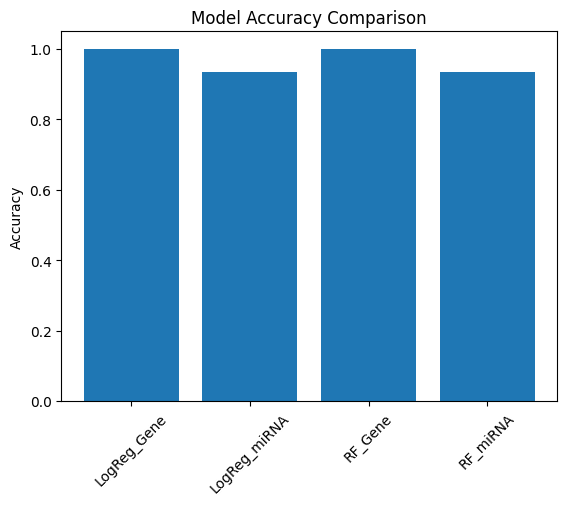

In [10]:
plt.figure()
plt.bar(results["Model"], results["Accuracy"])
plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()

### ROC-AUC Comparison

Visualize  model performance using ROC-AUC.

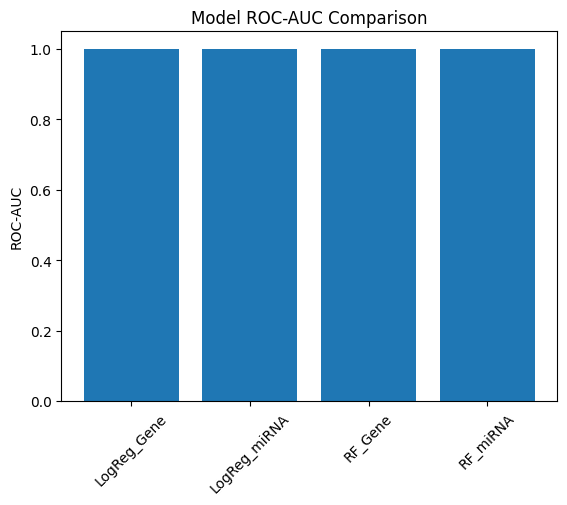

In [11]:
plt.figure()
plt.bar(results["Model"], results["ROC_AUC"])
plt.xticks(rotation=45)
plt.ylabel("ROC-AUC")
plt.title("Model ROC-AUC Comparison")
plt.show()

### ROC Curve Comparison

Visualize ROC curves for Logistic Regression and Random Forest models.

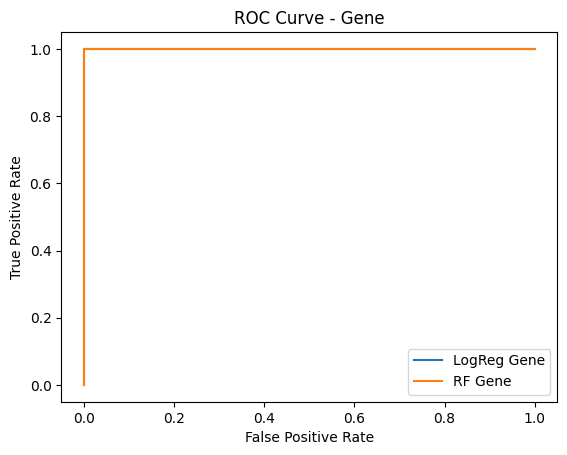

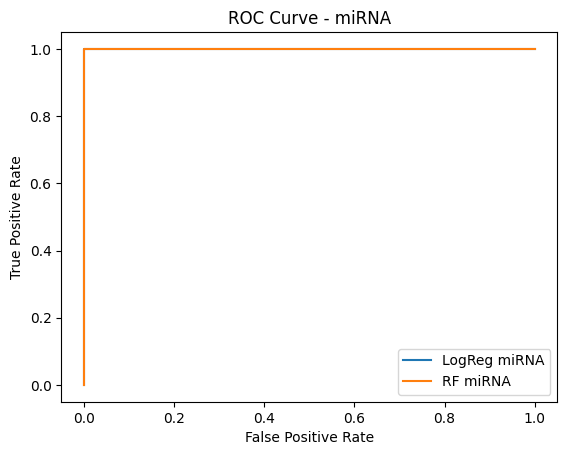

In [12]:
# Gene ROC Curves
fpr_lr_g, tpr_lr_g, _ = roc_curve(gene_preds["yg_test"], gene_preds["yg_prob_lr"])
fpr_rf_g, tpr_rf_g, _ = roc_curve(gene_preds["yg_test"], gene_preds["yg_prob_rf"])

plt.figure()
plt.plot(fpr_lr_g, tpr_lr_g, label="LogReg Gene")
plt.plot(fpr_rf_g, tpr_rf_g, label="RF Gene")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Gene")
plt.legend()
plt.show()

# miRNA ROC Curves
fpr_lr_m, tpr_lr_m, _ = roc_curve(mirna_preds["ym_test"], mirna_preds["ym_prob_lr"])
fpr_rf_m, tpr_rf_m, _ = roc_curve(mirna_preds["ym_test"], mirna_preds["ym_prob_rf"])

plt.figure()
plt.plot(fpr_lr_m, tpr_lr_m, label="LogReg miRNA")
plt.plot(fpr_rf_m, tpr_rf_m, label="RF miRNA")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - miRNA")
plt.legend()
plt.show()

### Confusion Matrices

Visualize classification performance using confusion matrices.

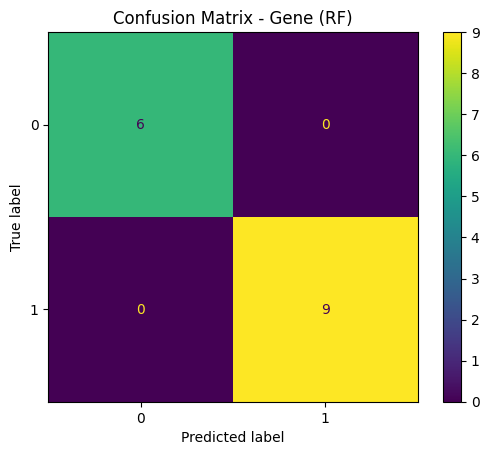

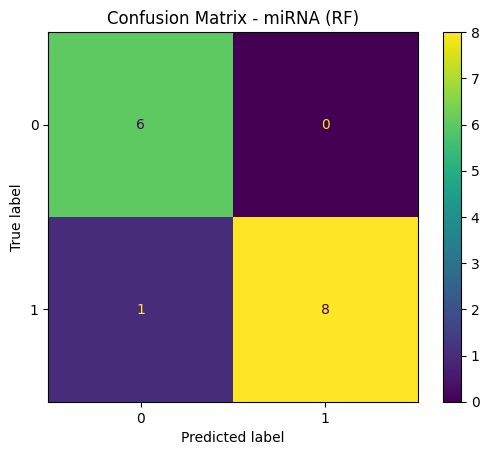

In [13]:
# Gene (Random Forest)
cm_g = confusion_matrix(gene_preds["yg_test"], gene_preds["yg_pred_rf"])
ConfusionMatrixDisplay(cm_g).plot()
plt.title("Confusion Matrix - Gene (RF)")
plt.show()

# miRNA (Random Forest)
cm_m = confusion_matrix(mirna_preds["ym_test"], mirna_preds["ym_pred_rf"])
ConfusionMatrixDisplay(cm_m).plot()
plt.title("Confusion Matrix - miRNA (RF)")
plt.show()